# Perhitungan Volume Kedua Lambung Kapal

**Mata Kuliah:** Analisis Numerik  
**Topik:** Perhitungan Volume  
**Nama:** [Oline Ola Fadhillah]  
**NPM:** [25083010028]  
**Kelas:** [A]

## 1. Deskripsi Permasalahan

Ketentuan yang digunakan dalam perhitungan adalah:

- Satu dash-kosong memiliki panjang 5 + 5 cm = 10 cm = 0,1 m.
- Lantai kapal dianggap datar dan tidak memiliki keel.
- Pada tampak depan, penampang lambung kapal dianggap berbentuk persegi panjang.
- Reserve buoyancy tidak dihitung.
- Perhitungan dilakukan untuk kedua lambung kapal.

## 2. Interpretasi Gambar

Gambar pada soal digunakan sebagai dasar untuk menentukan ukuran geometris kedua lambung kapal.

Dimensi yang diperlukan dalam perhitungan meliputi panjang, lebar, dan tinggi masing-masing lambung. Nilai dimensi tersebut akan diperoleh dengan menghitung jumlah grid pada gambar kemudian dikonversikan ke satuan meter.

In [139]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [140]:
grid_cm = 5 + 5
grid_m = grid_cm / 100

print(f"1 grid = {grid_cm} cm")
print(f"1 grid = {grid_m} m")

# Mengubah jumlah grid menjadi ukuran dalam meter
def grid_to_meter(jumlah_grid):
    return jumlah_grid * grid_m

print("Fungsi konversi grid ke meter berhasil dibuat.")

1 grid = 10 cm
1 grid = 0.1 m
Fungsi konversi grid ke meter berhasil dibuat.


### Interpretasi

Nilai 0,1 meter akan digunakan sebagai faktor konversi ketika jumlah grid pada gambar diubah menjadi ukuran sebenarnya dalam meter.

Dengan demikian, apabila suatu dimensi pada gambar memiliki panjang `n` grid, maka panjang sebenarnya dapat dihitung dengan:

$$
\text{Panjang sebenarnya} = n \times 0,1 \text{ meter}
$$

## 3. Menentukan Dimensi Lambung

Dimensi yang diperlukan meliputi:
- panjang lambung,
- lebar lambung,
- tinggi lambung.

Proses dimulai dengan membaca gambar, mendeteksi pola grid, menentukan jarak antar-grid, kemudian menggunakan hasil tersebut sebagai dasar konversi ukuran ke meter.

Ukuran gambar: (927, 643)


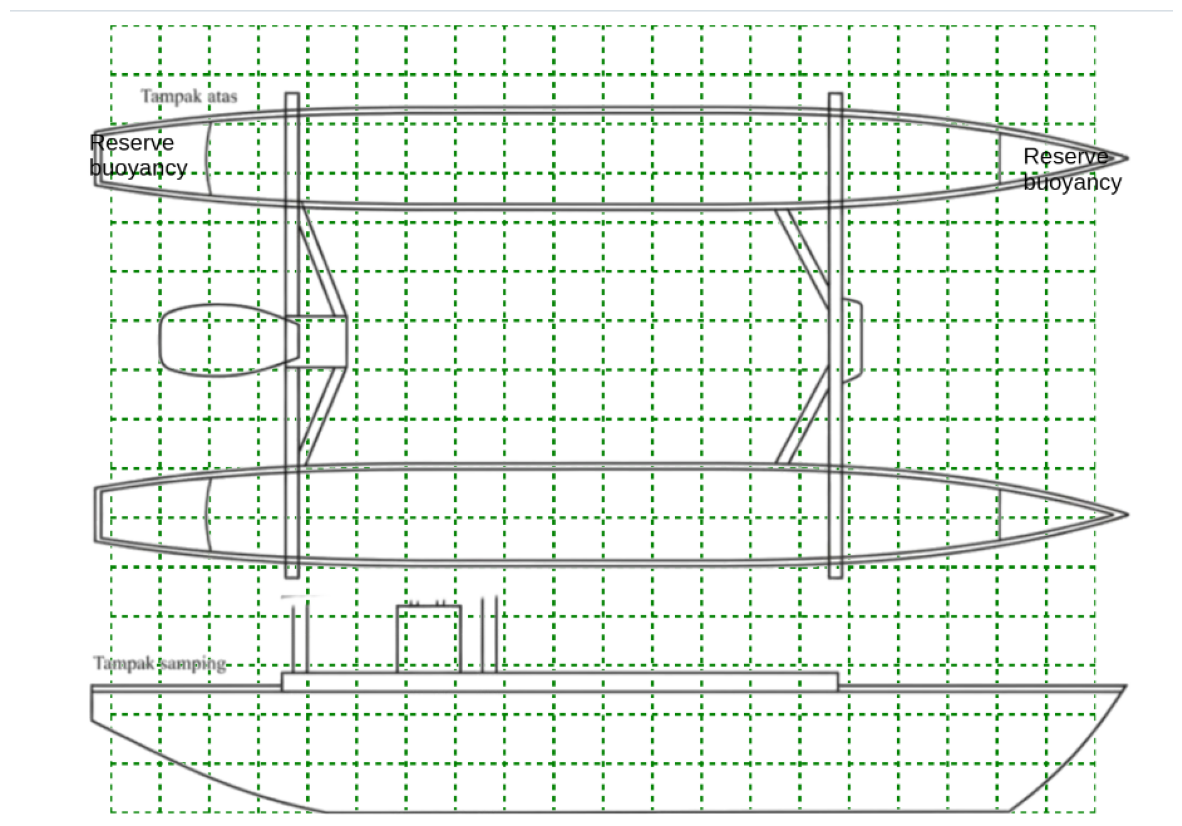

In [141]:
# Membaca gambar perahu yang akan dianalisis
from PIL import Image
import matplotlib.pyplot as plt

gambar = Image.open("perahu_page1.png")

print("Ukuran gambar:", gambar.size)

plt.figure(figsize=(15, 100))
plt.imshow(gambar)
plt.axis("off")
plt.show()

In [ ]:
import numpy as np

data = np.array(gambar)

# Membuat mask untuk mendeteksi warna hijau pada grid
mask_hijau = (
    (data[:, :, 0] < 50) &
    (data[:, :, 1] > 80) &
    (data[:, :, 2] < 50)
)

# Menghitung jumlah piksel hijau pada setiap baris dan kolom
jumlah_hijau_baris = mask_hijau.sum(axis=1)
jumlah_hijau_kolom = mask_hijau.sum(axis=0)

print("Deteksi garis grid berhasil dilakukan.")

Deteksi garis grid berhasil dilakukan.


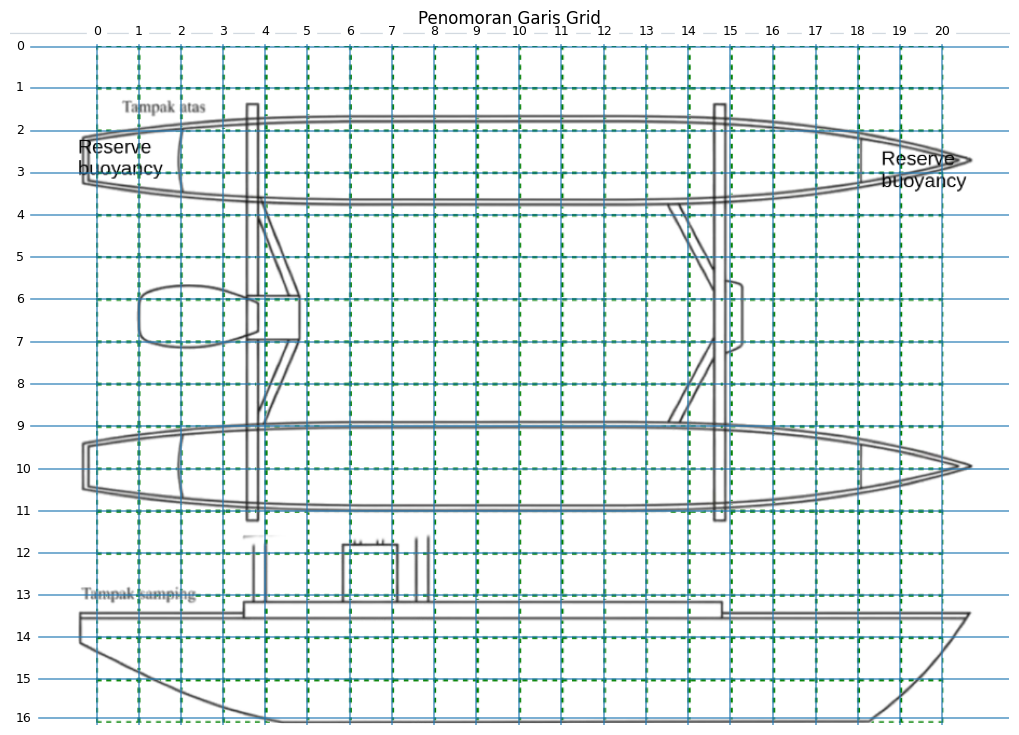

In [193]:
plt.figure(figsize=(14, 9))
plt.imshow(gambar)

for i, x in enumerate(garis_vertikal_lengkap):
    plt.axvline(
        x=x,
        linewidth=1.2,
        alpha=0.7
    )
    plt.text(
        x,
        5,
        str(i),
        ha="center",
        va="bottom",
        fontsize=9,
        backgroundcolor="white"
    )

for i, y in enumerate(garis_horizontal_lengkap):
    plt.axhline(
        y=y,
        linewidth=1.2,
        alpha=0.7
    )
    plt.text(
        5,
        y,
        str(i),
        ha="left",
        va="center",
        fontsize=9,
        backgroundcolor="white"
    )

plt.title("Penomoran Garis Grid")
plt.axis("off")
plt.show()

In [194]:
# Mengelompokkan posisi piksel yang berdekatan menjadi satu garis grid
def kelompokkan_garis(posisi, jarak_maks=5):
    kelompok = []

    if len(posisi) == 0:
        return np.array([])

    sementara = [posisi[0]]

    for i in range(1, len(posisi)):
        if posisi[i] - posisi[i - 1] <= jarak_maks:
            sementara.append(posisi[i])
        else:
            kelompok.append(sementara)
            sementara = [posisi[i]]

    kelompok.append(sementara)

    # Mengambil titik tengah setiap kelompok sebagai posisi garis
    pusat_garis = [int(np.mean(k)) for k in kelompok]

    return np.array(pusat_garis)


# Mengelompokkan garis horizontal dan vertikal
garis_horizontal = kelompokkan_garis(kandidat_baris)
garis_vertikal = kelompokkan_garis(kandidat_kolom)

print("Jumlah garis horizontal :", len(garis_horizontal))
print("Jumlah garis vertikal   :", len(garis_vertikal))

Jumlah garis horizontal : 16
Jumlah garis vertikal   : 20


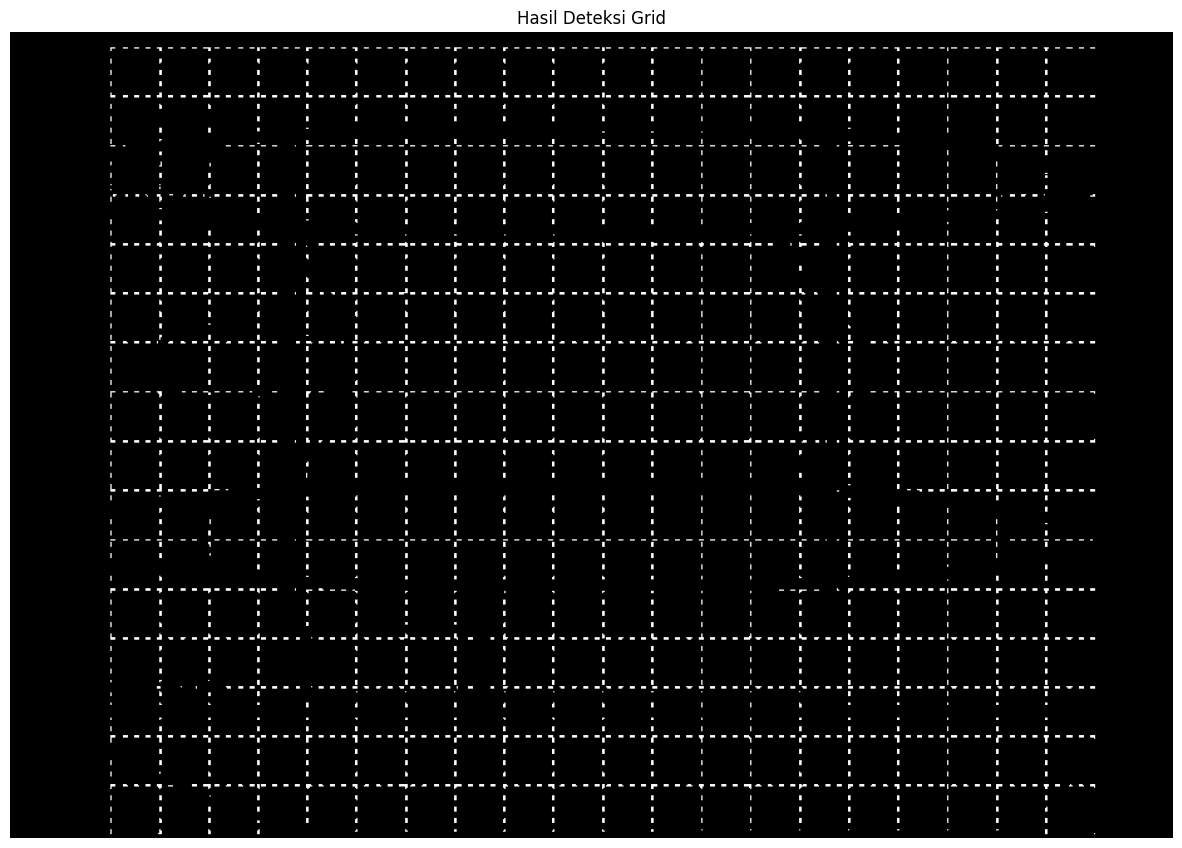

In [143]:
# Menampilkan area gambar yang terdeteksi sebagai garis grid
plt.figure(figsize=(15, 100))
plt.imshow(mask_hijau, cmap="gray")
plt.title("Hasil Deteksi Grid")
plt.axis("off")
plt.show()

In [146]:
# Menghitung jarak antar garis grid dalam satuan piksel
jarak_vertikal = np.diff(garis_vertikal)
jarak_horizontal = np.diff(garis_horizontal)

print("Jarak antar garis vertikal (pixel):")
print(jarak_vertikal)

print("\nJarak antar garis horizontal (pixel):")
print(jarak_horizontal)

Jarak antar garis vertikal (pixel):
[39 39 39 39 39 40 39 39 39 40 39 40 39 39 39 39 40 39 39]

Jarak antar garis horizontal (pixel):
[38 40 39 39 39 39 40 39 39 40 39 39 39 39 39]


In [ ]:
pixel_per_grid_x = rata_rata_grid_vertikal
pixel_per_grid_y = rata_rata_grid_horizontal

# Menentukan ukuran satu grid berdasarkan instruksi soal
meter_per_grid = 0.1
print(f"Jarak satu grid arah X : {pixel_per_grid_x:.2f} pixel")
print(f"Jarak satu grid arah Y : {pixel_per_grid_y:.2f} pixel")
print(f"Ukuran satu grid       : {meter_per_grid} meter")

Jarak satu grid arah X : 39.21 pixel
Jarak satu grid arah Y : 39.13 pixel
Ukuran satu grid       : 0.1 meter


### Interpretasi

Berdasarkan hasil deteksi, satu grid memiliki ukuran sekitar 39,21 piksel pada arah X dan 39,13 piksel pada arah Y. Sementara itu, berdasarkan instruksi soal, satu grid memiliki ukuran 0,1 meter.

Dengan demikian, jarak dalam piksel dapat dikonversikan menjadi jumlah grid, kemudian jumlah grid tersebut dikonversikan menjadi ukuran sebenarnya dalam meter. Skala ini akan digunakan untuk mengukur panjang, lebar, dan tinggi lambung kapal.

## 4. Menghitung Panjang Lambung

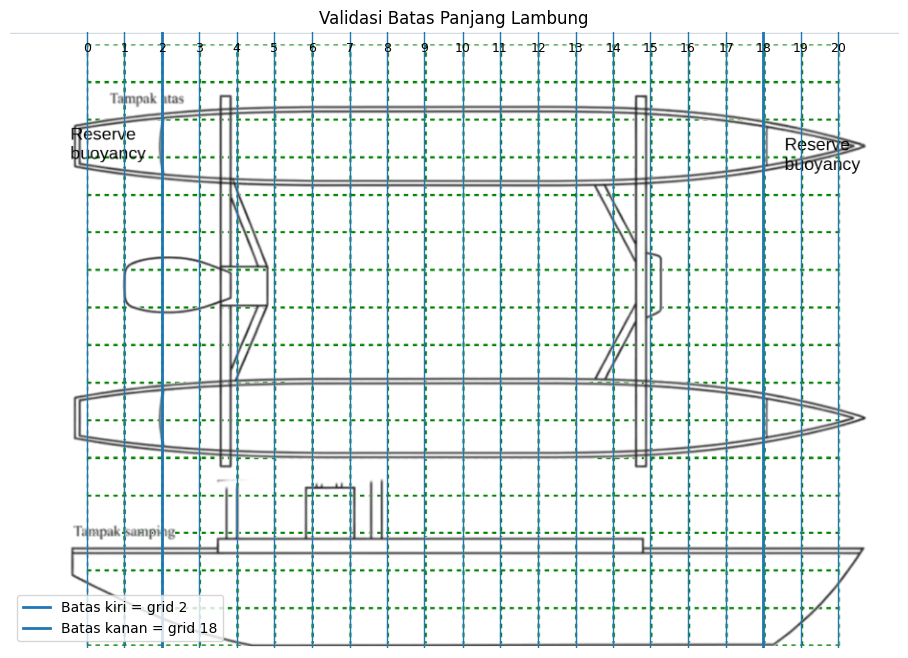

In [195]:
plt.figure(figsize=(15, 8))
plt.imshow(gambar)

for i, x in enumerate(garis_vertikal_lengkap):
    plt.axvline(x, linewidth=1)
    plt.text(x, 20, str(i), fontsize=9, ha="center")


# Garis batas kiri dan kanan
plt.axvline(
    garis_vertikal_lengkap[grid_awal_lambung],
    linewidth=2,
    label=f"Batas kiri = grid {grid_awal_lambung}"
)

plt.axvline(
    garis_vertikal_lengkap[grid_akhir_lambung],
    linewidth=2,
    label=f"Batas kanan = grid {grid_akhir_lambung}"
)

plt.title("Validasi Batas Panjang Lambung")
plt.legend()
plt.axis("off")
plt.show()

In [189]:
# Menentukan batas awal dan akhir lambung yang akan dihitung

grid_awal_lambung = 2
grid_akhir_lambung = 18

print(f"Grid awal lambung  : {grid_awal_lambung}")
print(f"Grid akhir lambung : {grid_akhir_lambung}")

Grid awal lambung  : 2
Grid akhir lambung : 18


In [167]:
# Menghitung panjang lambung berdasarkan batas grid
jumlah_grid_panjang = grid_akhir_lambung - grid_awal_lambung

# Mengonversi jumlah grid menjadi meter
panjang_lambung = jumlah_grid_panjang * meter_per_grid

print(f"Jumlah grid panjang : {jumlah_grid_panjang}")
print(f"Panjang lambung     : {panjang_lambung:.2f} meter")

Jumlah grid panjang : 16
Panjang lambung     : 1.60 meter


### Interpretasi

Berdasarkan batas grid yang telah divalidasi, bagian lambung yang dihitung memiliki panjang 16 interval grid. Karena setiap grid memiliki ukuran 0,1 meter, panjang lambung diperoleh sebesar 1,60 meter.

Perhitungan dilakukan secara otomatis berdasarkan selisih indeks grid sehingga tidak memerlukan pengukuran panjang secara manual.

## 4. Menghitung Lebar Lambung

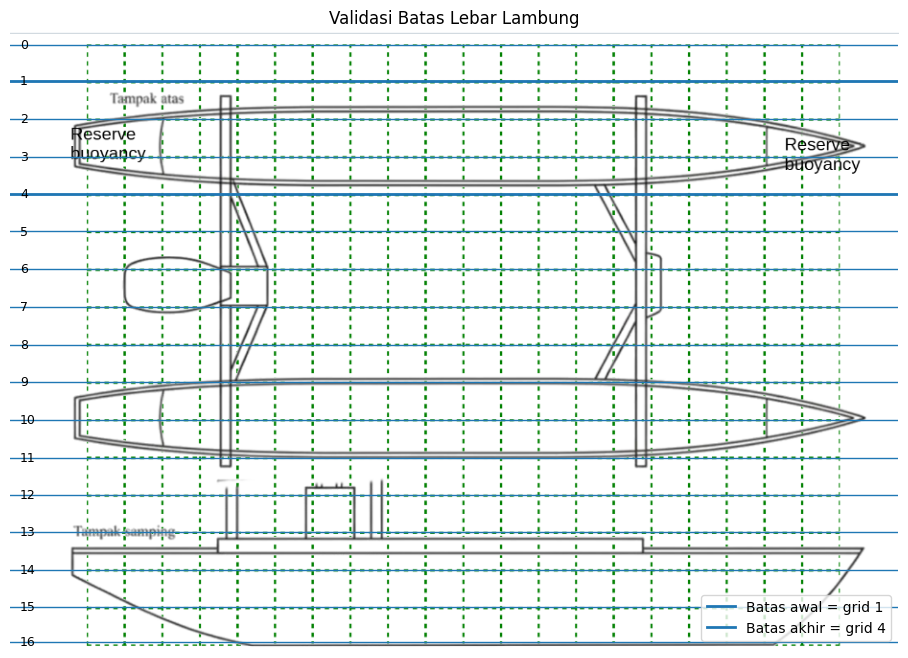

In [190]:
# Memvalidasi batas lebar lambung berdasarkan tampak atas

plt.figure(figsize=(14, 8))
plt.imshow(gambar)

for i, y in enumerate(garis_horizontal_lengkap):
    plt.axhline(y, linewidth=1)
    plt.text(
        10,
        y,
        str(i),
        fontsize=9,
        va="center"
    )

plt.axhline(
    garis_horizontal_lengkap[grid_awal_lebar],
    linewidth=2,
    label=f"Batas awal = grid {grid_awal_lebar}"
)

plt.axhline(
    garis_horizontal_lengkap[grid_akhir_lebar],
    linewidth=2,
    label=f"Batas akhir = grid {grid_akhir_lebar}"
)

plt.title("Validasi Batas Lebar Lambung")
plt.legend()
plt.axis("off")
plt.show()

In [196]:
# Menentukan batas lebar lambung berdasarkan tampak atas

grid_awal_lebar = 1
grid_akhir_lebar = 4

print(f"Grid awal lebar  : {grid_awal_lebar}")
print(f"Grid akhir lebar : {grid_akhir_lebar}")


Grid awal lebar  : 1
Grid akhir lebar : 4


In [170]:
# Menghitung lebar lambung berdasarkan selisih grid
jumlah_grid_lebar = grid_akhir_lebar - grid_awal_lebar

# Mengonversi jumlah grid menjadi meter
lebar_lambung = jumlah_grid_lebar * meter_per_grid

print(f"Jumlah grid lebar : {jumlah_grid_lebar}")
print(f"Lebar lambung     : {lebar_lambung:.2f} meter")

Jumlah grid lebar : 3
Lebar lambung     : 0.30 meter


### Interpretasi

Berdasarkan hasil validasi visual, batas lebar lambung ditentukan dari grid 1 sampai grid 4. Rentang tersebut mencakup keseluruhan bagian lambung yang akan dihitung.

Terdapat 3 interval grid dengan ukuran setiap grid sebesar 0,1 meter, sehingga lebar satu lambung diperoleh sebesar 0,30 meter. Nilai ini selanjutnya digunakan dalam perhitungan volume lambung kapal.

## 5. Menghitung Tinggi Lambung

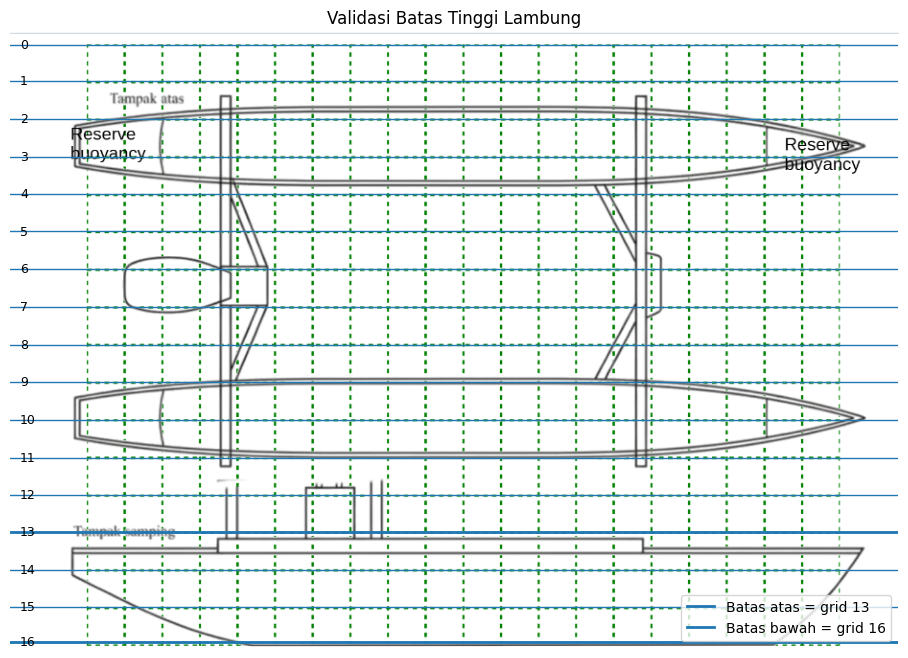

In [197]:
# Menampilkan tinggi lambung pada gambar

plt.figure(figsize=(14, 8))
plt.imshow(gambar)

for i, y in enumerate(garis_horizontal_lengkap):
    plt.axhline(y, linewidth=1)
    plt.text(
        10,
        y,
        str(i),
        fontsize=9,
        va="center"
    )
plt.axhline(
    garis_horizontal_lengkap[grid_awal_tinggi],
    linewidth=2,
    label=f"Batas atas = grid {grid_awal_tinggi}"
)

plt.axhline(
    garis_horizontal_lengkap[grid_akhir_tinggi],
    linewidth=2,
    label=f"Batas bawah = grid {grid_akhir_tinggi}"
)

plt.title("Validasi Batas Tinggi Lambung")
plt.legend()
plt.axis("off")
plt.show()

In [ ]:
# Batas akan divalidasi melalui visualisasi

grid_awal_tinggi = 13
grid_akhir_tinggi = 16

print(f"Grid awal tinggi  : {grid_awal_tinggi}")
print(f"Grid akhir tinggi : {grid_akhir_tinggi}")

Grid awal tinggi  : 13
Grid akhir tinggi : 16


In [ ]:
jumlah_grid_tinggi = grid_akhir_tinggi - grid_awal_tinggi
tinggi_lambung = jumlah_grid_tinggi * meter_per_grid

print(f"Jumlah grid tinggi : {jumlah_grid_tinggi}")
print(f"Tinggi lambung     : {tinggi_lambung:.2f} meter")

Jumlah grid tinggi : 3
Tinggi lambung     : 0.30 meter


## 6. Menghitung Volume Lambung

In [174]:
# Menghitung volume satu lambung dan volume kedua lambung

volume_satu_lambung = panjang_lambung * lebar_lambung * tinggi_lambung

jumlah_lambung = 2
volume_kedua_lambung = volume_satu_lambung * jumlah_lambung

print(f"Volume satu lambung   : {volume_satu_lambung:.4f} m³")
print(f"Jumlah lambung        : {jumlah_lambung}")
print(f"Volume kedua lambung  : {volume_kedua_lambung:.4f} m³")

Volume satu lambung   : 0.1440 m³
Jumlah lambung        : 2
Volume kedua lambung  : 0.2880 m³


## Ringkasan Hasil Perhitungan


In [198]:
# Menampilkan ringkasan seluruh dimensi dan hasil volume

print("===== RINGKASAN HASIL PERHITUNGAN =====")
print(f"Panjang lambung       : {panjang_lambung:.2f} m")
print(f"Lebar lambung         : {lebar_lambung:.2f} m")
print(f"Tinggi lambung        : {tinggi_lambung:.2f} m")
print(f"Jumlah lambung        : {jumlah_lambung}")
print(f"Volume satu lambung   : {volume_satu_lambung:.4f} m³")
print(f"Volume kedua lambung  : {volume_kedua_lambung:.4f} m³")

===== RINGKASAN HASIL PERHITUNGAN =====
Panjang lambung       : 1.60 m
Lebar lambung         : 0.30 m
Tinggi lambung        : 0.30 m
Jumlah lambung        : 2
Volume satu lambung   : 0.1440 m³
Volume kedua lambung  : 0.2880 m³


Berdasarkan hasil pengukuran menggunakan grid pada gambar kapal, diperoleh dimensi satu lambung sebagai berikut:

- Panjang lambung = 1,60 m
- Lebar lambung = 0,30 m
- Tinggi lambung = 0,30 m
- Jumlah lambung yang dihitung = 2

Volume satu lambung dihitung menggunakan pendekatan:

$$
V = P \times L \times T
$$

Sehingga:

$$
V = 1,60 \times 0,30 \times 0,30
$$

$$
V = 0,144\ m^3
$$

Karena terdapat dua lambung:

$$
V_{total} = 2 \times 0,144
$$

$$
\boxed{V_{total}=0,288\ m^3}
$$

Volume *reserve buoyancy* tidak termasuk dalam perhitungan.